In [6]:
# notebook utilities
%load_ext autoreload
%autoreload 2

# standard library
import pickle
from collections import defaultdict
from pathlib import Path

# third party
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import contextily as cx
import pyomo.environ as pyo
from tqdm.notebook import tqdm

# local modules
import src.data_utilities as du
import src.viz as vz
import src.mc_heuristics as mch
import src.mc_solvers as mcs

In [7]:
def check_gurobi_license() -> bool:
    """Check whether a Gurobi license is available.

    Returns
    -------
    bool
        True if a license can be acquired, False otherwise.
    """
    try: 
        import gurobipy as gp
        try:
            env = gp.Env(empty=True)
            env.start()
            env.dispose()
            return True
        except gp.GurobiError:
            return False
    except ImportError:
        return False

can_acquire_license = check_gurobi_license()

print('Gurobi license available:', can_acquire_license)

run_gurobi = can_acquire_license

Set parameter Username
Set parameter LicenseID to value 2749948
Academic license - for non-commercial use only - expires 2026-12-04
Gurobi license available: True


In [8]:
matrix_code_folder = Path( './../distance_matrix/' )
data_folder = matrix_code_folder / 'generated_data_and_distances' / 'vietnam'
fig_folder = Path( './generated/figures/' )
benchmark_folder = matrix_code_folder / 'cases' / 'Fleur' / 'benchmark'
pop_folder = data_folder / 'facebook/'

fig_folder.mkdir(parents=True, exist_ok=True)

In [9]:
current_hospitals = pd.read_pickle(data_folder / 'current_hospitals.pkl')
pop = pd.read_pickle(pop_folder / 'population.pkl')

In [10]:
f'{len(pop):,} {len(current_hospitals):,}'

'406,784 80'

In [11]:
stats = []
data = {}

subFolders = sorted(
    [entry for entry in Path(pop_folder).iterdir() if entry.is_dir()],
    key=du.numeric_sort_key,
    reverse=True
)

for casus in subFolders:
    try:
        allHospitals = pd.read_pickle((casus / 'all_hospitals').with_suffix('.pkl'))
        newHospitals = pd.read_pickle((casus / 'new_hospitals').with_suffix('.pkl'))
        distances = pd.read_pickle((casus / 'distances_osm_max_300km').with_suffix('.pkl'))

        data[casus.name] = {
            'allHospitals': allHospitals,
            'newHospitals': newHospitals,
            'distances': distances
        }

        stats.append({
            'casus': casus.name,
            'nAllHospitals': len(allHospitals),
            'nNewHospitals': len(newHospitals),
            'nPopInDistanceData': distances.pop_id.nunique(),
            'nHospitalsInDistanceData': distances.hosp_id.nunique()
        })
    except FileNotFoundError as e:
        print(f'Skipped {casus.name}: missing file ({e})')
    except Exception as e:
        print(f'Error in {casus.name}: {e}')

pd.DataFrame(stats).set_index('casus').to_clipboard()


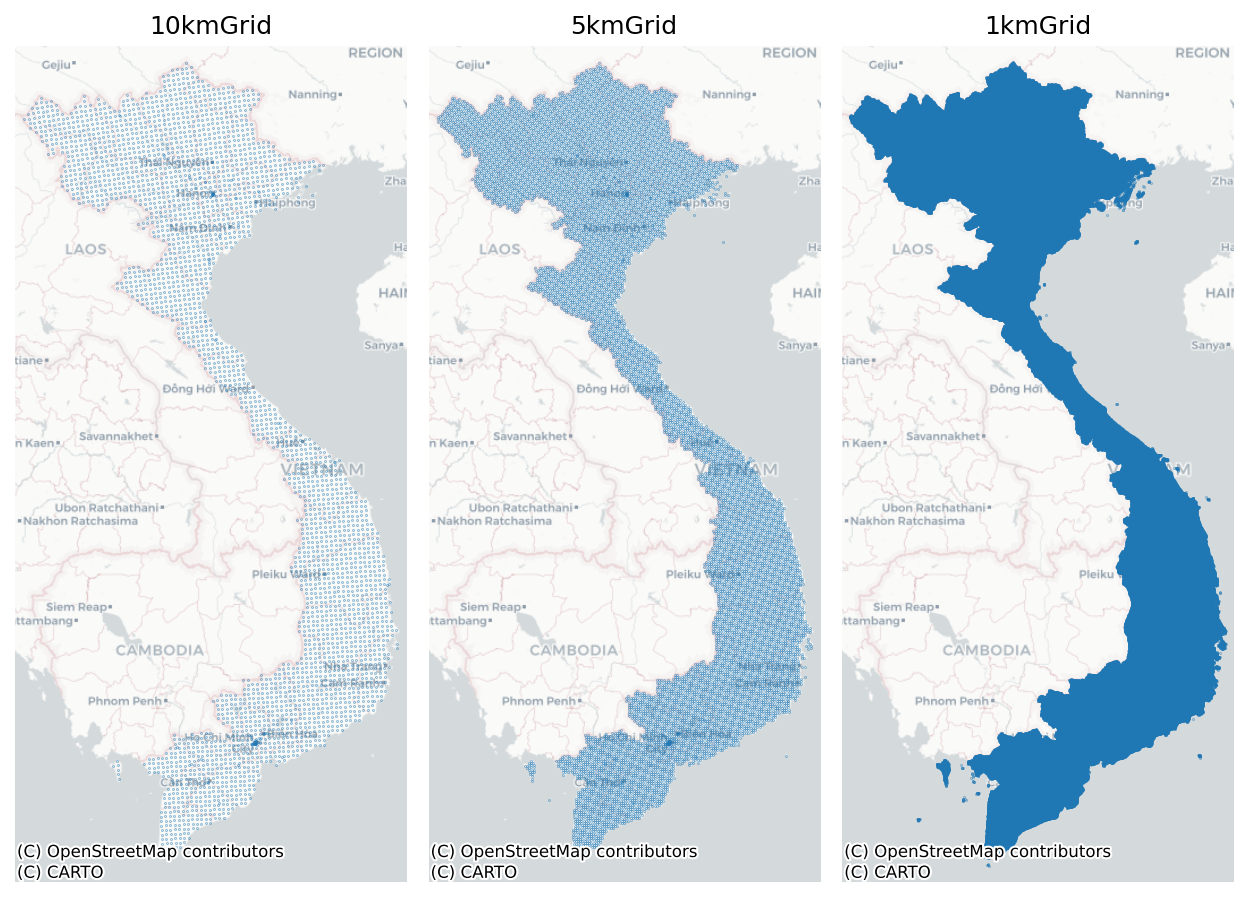

In [12]:
points_list = [
    gpd.GeoSeries(
        gpd.points_from_xy(d['allHospitals']['Longitude'], d['allHospitals']['Latitude']),
        crs='EPSG:4326',
    )
    for d in data.values()
]

vz.plot_points_with_basemap_grid(
    points_list,
    titles=[f'{s}' for s in data.keys()],
    nrows=1,
    markersize=0.05,
    alpha=0.9,
    filename=fig_folder / 'viz_all_hospitals.png',
)

In [13]:
def create_instance_from_vietnam(grid: int, threshold: float, data=data, pop=pop, pop_folder=pop_folder) -> dict:
    casus = f'{grid}kmGrid'
    if casus not in data:
        raise ValueError(f'No data for grid={grid}')

    result = {
        'row': None,
        'col': None,
        'pop': pop.set_index('ID',drop=True),
        'fac': du.load_any( pop_folder / casus / 'all_hospitals.pkl' ).set_index('ID',drop=True),
    }

    result['HH'] = result['pop']['household_count'].to_numpy()
    result['pop'] = result['pop'][['ycoord', 'xcoord']]
    result['fac'] = result['fac'][['Latitude', 'Longitude']]
    
    result['row'] = du.build_mapping(
        data[casus]['distances'],
        threshold=threshold,
        key_col='hosp_id',
        value_col='pop_id',
    )
    result['col'] = du.reverse_mapping(result['row'])

    return result

In [ ]:
%%time 

datasets_folder = Path( './generated/datasets/' )
datasets_file = datasets_folder / 'datasets.pkl'
datasets_file.parent.mkdir(parents=True, exist_ok=True)

if datasets_file.exists():
    with open(datasets_file, 'rb') as f:
        DATASETS = pickle.load(f)
else:
    def ensure_sorted_mapping(mapping: dict[int, np.ndarray | list[int]]) -> dict[int, np.ndarray]:
        '''
        Ensure a mapping i -> array[j] has sorted keys and sorted values.

        Parameters
        ----------
        mapping
            Dictionary mapping keys to lists or arrays.

        Returns
        -------
        dict[int, np.ndarray]
            Mapping with sorted keys and sorted numpy arrays (int32).
        '''
        return {
            int(k): np.sort(np.asarray(v, dtype=np.int32))
            for k, v in sorted(mapping.items())
        }
        
    DATASETS: dict[str, dict[str, object]] = {
        'kings': {
            'row': du.load_any(benchmark_folder / 'kings_row.pkl'),
            'col': du.load_any(benchmark_folder / 'kings_col.pkl'),
            'pop': du.load_any(benchmark_folder / 'Kings.dat'),
        },
    }

    DATASETS['kings']['row'] = ensure_sorted_mapping(DATASETS['kings']['row'])
    DATASETS['kings']['col'] = ensure_sorted_mapping(DATASETS['kings']['col'])

    DATASETS['kings']['HH'] = DATASETS['kings']['pop'][:, -1]
    DATASETS['kings']['pop'] = DATASETS['kings']['pop'][:, :2]
    DATASETS['kings']['fac'] = DATASETS['kings']['pop']

    for g in [10, 5, 1]:
        for t in [5, 10, 50, 100, 200]:
            print(f'Creating instance for grid={g:>2}km, threshold={t:>3}km...')
            DATASETS[f'vietnam_{g}_{t}'] = create_instance_from_vietnam(g, t)

    with open(datasets_file, 'wb') as f:
        pickle.dump(DATASETS, f)

CPU times: total: 2.72 s
Wall time: 3.1 s


Although useful for visualizing the spatial resolution of potential facility candidate sets, the grid data presented above may not be fully consistent with the remaining datasets. 

Therefore, in the sequel we restrict attention to three internally consistent datasets curated by Fleur Theulen:

- The Kings instance from Vinícius R. Máximo, Mariá C.V. Nascimento, André C.P.L.F. Carvalho, Intelligent-guided adaptive search for the maximum covering location problem, Computers & Operations Research, Volume 78, 2017, Pages 129-137,
- The Vietnam national instance at 10 km resolution  
- The Vietnam national instance at 5 km resolution  
- The Vietnam national instance at 1 km resolution  

This ensures methodological consistency across experiments and avoids distortions introduced by heterogeneous preprocessing pipelines.

In [15]:
def mapping_density_ij(
    mapping: dict,
    n: int,
    m: int,
) -> float:
    """
    Compute density of pairs (i, j) encoded as i -> list[j], relative to n*m.

    Assumes the lists contain unique j per i. If not, consider deduplicating.
    """
    if n <= 0 or m <= 0:
        raise ValueError('n and m must be positive.')

    num_pairs: int = sum(len(js) for js in mapping.values())
    return num_pairs / (n * m)

In [16]:
heuristic_results = {}

for dataset, actual_data in DATASETS.items():
    n = actual_data['pop'].shape[0]
    m = actual_data['fac'].shape[0]
    density = mapping_density_ij(actual_data['col'], n, m)
    w = actual_data['HH']
    JI = actual_data['row']
    IJ = actual_data['col']
    I = np.fromiter(IJ.keys(), dtype=int)
    covered_pop = w[I].sum()
    instance = mch.build_instance(
        w=w,
        IJ=IJ,
        JI=JI,
        assume_unique_sorted=True,
    )
    greedy_result, reduced_result, restricted, lifted_result = mch.greedy_drop_greedy(instance)
    assert greedy_result.objective == reduced_result.objective, "Greedy and reduced greedy should have the same objective"
    assert lifted_result.objective == covered_pop, "Lifted solution should cover the whole reacheable population"
    heuristic_results[dataset] = {
        'greedy': greedy_result,
        'reduced': reduced_result,
        'restricted': restricted,
        'lifted': lifted_result,
    }  
    print(
        f'{dataset:>20}: ('
        f'{n:>8,} x '
        f'{m:>7,})'
        f' density = {density:.3%}'
        f', reduced greedy coverage = {lifted_result.objective:>13,} ({lifted_result.objective / w.sum():7.2%})'
        f' obtained in {lifted_result.total_time:3.2f} seconds'   
    )

               kings: (   7,730 x   7,730) density = 1.304%, reduced greedy coverage =     2,504,700 (100.00%) obtained in 0.12 seconds
        vietnam_10_5: ( 406,784 x   3,635) density = 0.005%, reduced greedy coverage =    33,875,812 ( 34.80%) obtained in 1.28 seconds
       vietnam_10_10: ( 406,784 x   3,635) density = 0.017%, reduced greedy coverage =    70,884,039 ( 72.82%) obtained in 2.32 seconds
         vietnam_5_5: ( 406,784 x  14,315) density = 0.004%, reduced greedy coverage =    75,325,720 ( 77.39%) obtained in 2.12 seconds
        vietnam_5_10: ( 406,784 x  14,315) density = 0.017%, reduced greedy coverage =    94,981,864 ( 97.58%) obtained in 2.93 seconds


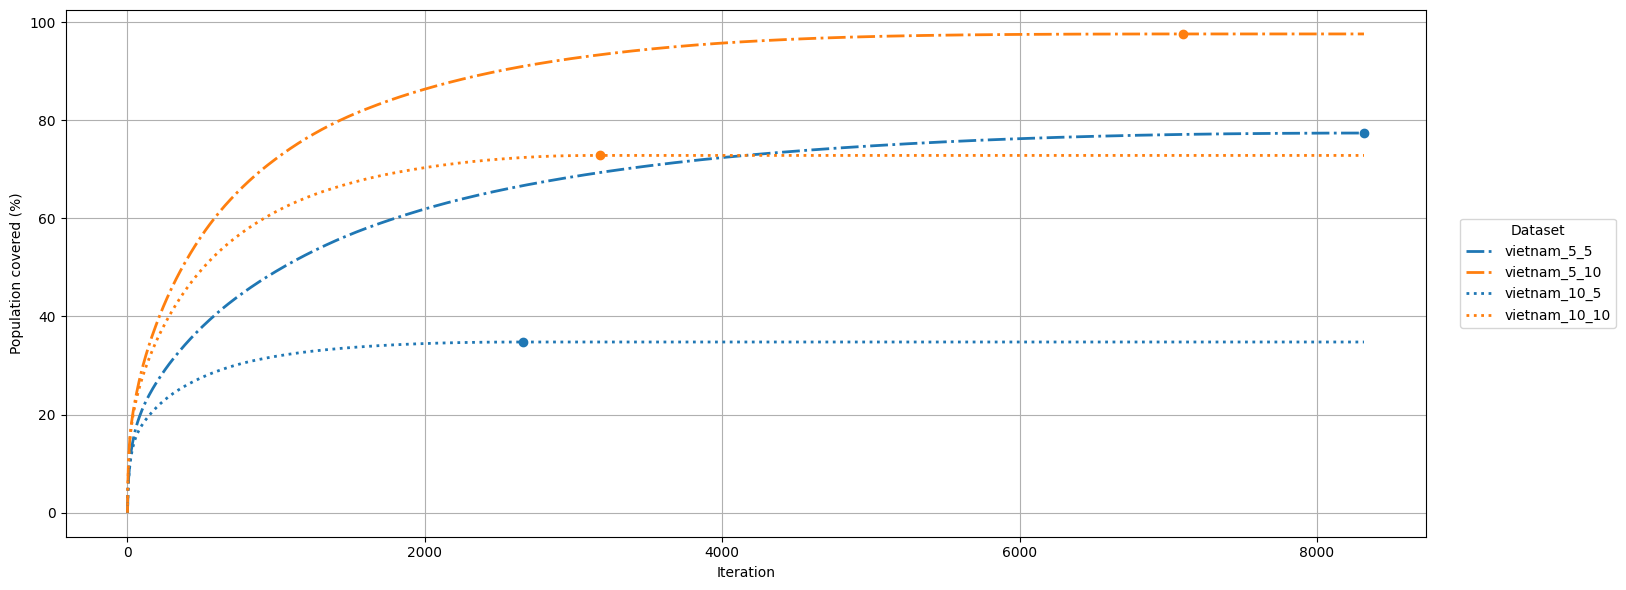

In [17]:
df = pd.DataFrame(
    {
        dataset: mch.greedy_result_to_dataframe(results['lifted'])['value']
        for dataset, results in heuristic_results.items()
        if dataset.startswith('vietnam_')
    }
) / w.sum() * 100
df = df.ffill()


def parse_dataset(name: str) -> tuple[int, int]:
    '''
    Extract x and y from a dataset name of the form 'vietnam_x_y'.

    Parameters
    ----------
    name:
        Dataset name.

    Returns
    -------
    tuple[int, int]
        The pair (x, y).

    Raises
    ------
    ValueError
        If the dataset name does not match the expected format.
    '''
    parts = name.split('_')
    if len(parts) != 3 or parts[0] != 'vietnam':
        raise ValueError(f'Unexpected dataset name: {name!r}')
    return int(parts[1]), int(parts[2])


def first_plateau_index(series: pd.Series) -> int:
    '''
    Return the first index at which the series reaches its final value.

    This is useful after forward filling, where the horizontal tail starts
    exactly at the first occurrence of the final plateau value.

    Parameters
    ----------
    series:
        Trace values indexed by iteration.

    Returns
    -------
    int
        The first iteration index where the final value is attained.
    '''
    final_value = series.iloc[-1]
    mask = series.eq(final_value)
    return int(mask[mask].index[0])


# Sort columns so legend is grouped by x, then by y.
ordered_cols = sorted(df.columns, key=parse_dataset)

# Unique parameter values.
xs = sorted({parse_dataset(col)[0] for col in ordered_cols})
ys = sorted({parse_dataset(col)[1] for col in ordered_cols})

# Same linestyle for same x.
linestyle_map: dict[int, str] = {
    1: '-',
    5: '-.',
    10: ':',
}

# Same color for same y.
cmap = plt.get_cmap('tab10')
color_map: dict[int, tuple[float, float, float, float]] = {
    y: cmap(i % 10) for i, y in enumerate(ys)
}

fig, ax = plt.subplots(figsize=(20, 6))

handles: list = []
labels: list[str] = []

for col in ordered_cols:
    x, y = parse_dataset(col)
    series = df[col]

    line, = ax.plot(
        series.index,
        series.values,
        color=color_map[y],
        linestyle=linestyle_map.get(x, '-'),
        linewidth=2,
        label=col,
    )

    plateau_idx = first_plateau_index(series)
    plateau_value = float(series.loc[plateau_idx])

    ax.plot(
        plateau_idx,
        plateau_value,
        marker='o',
        markersize=6,
        color=color_map[y],
    )

    handles.append(line)
    labels.append(col)

ax.set_xlabel('Iteration')
ax.set_ylabel('Population covered (%)')
ax.grid(True)

# Legend outside, 3 columns, ordered by x.
ax.legend(
    handles,
    labels,
    # ncol=3,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title='Dataset',
)

# Leave room on the right for the outside legend.
plt.tight_layout(rect=(0, 0, 0.82, 1))
plt.savefig( fig_folder / 'vietname.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

In [18]:
case = 'vietnam_10_10'

w = DATASETS[case]['HH']
JI = DATASETS[case]['row']
IJ = DATASETS[case]['col']
I = np.fromiter(IJ.keys(), dtype=int)
J = np.fromiter(JI.keys(), dtype=int)

nJ = len(np.unique(np.concatenate(tuple(IJ.values()))))
nI = len(np.unique(np.concatenate(tuple(JI.values()))))

assert nI == len(I), f'Expected nI={nI} but got {len(I)}'
assert nJ == len(J), f'Expected nJ={nJ} but got {len(J)}'

tot_pop = w.sum()
covered_pop = w[I].sum()
print(f'Total population: {tot_pop:,}, Covered population: {covered_pop:,} ({covered_pop/tot_pop:.2%})')

Total population: 97,338,396.0, Covered population: 70,884,039.0 (72.82%)


In [ ]:
fig, ax = vz.plot_points_with_tiles_generic(
    layers=[
        {
            'xy': DATASETS[case]['pop'],
            'order': 'latlon',
            'style': {'color': 'black', 'markersize': .1, 'alpha': 0.9},
            'label': 'POP',
        },
        {
            'xy': DATASETS[case]['fac'],
            'order': 'latlon',
            'style': {'color': 'red', 'markersize': 9, 'alpha': 0.1},
            'label': 'FAC',
        },
    ],
    provider=cx.providers.CartoDB.Voyager,
)
ax.set_title(f'{case} dataset with max covering {covered_pop/tot_pop:.2%}')
fig.savefig(fig_folder / f'viz_{case}.png', dpi=300, bbox_inches='tight')

In [ ]:
instance = mch.build_instance(
    w=w,
    IJ=IJ,
    JI=JI,
    assume_unique_sorted=True,
)

NameError: name 'mch' is not defined

In [ ]:
result_greedy = mch.greedy_construct(instance)

NameError: name 'mch' is not defined

In [ ]:
result_reduced_greedy = mch.drop_redundant_facilities(
    instance=instance,
    solution=result_greedy.solution,
    coverage=result_greedy.coverage,
    objective=result_greedy.objective,
)

NameError: name 'mch' is not defined

In [ ]:
len(result_greedy.solution),len(result_reduced_greedy.solution)

NameError: name 'result_greedy' is not defined

In [ ]:
def plot_greedy_trace(
    result_greedy,
    tot_pop: int | float,
    strategy: str,
    case: str,
    covered_pop: int | float,
    filename: Path | None = None,
) -> None:
    '''Plot the greedy objective trace as percentage of population covered.'''
    import matplotlib.pyplot as plt

    (
        mch.greedy_result_to_dataframe(result_greedy)['value'] / tot_pop * 100
    ).plot(
        grid=True,
        figsize=(20, 6),
        style='-',
        linewidth=2,
        title=(
            f'{strategy} objective trace for {case} '
            f'(max covering {covered_pop / tot_pop:.2%}) '
            f'obtained in {result_greedy.total_time:.2f} seconds'
        ),
    )

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight')

    plt.show()
    plt.close()

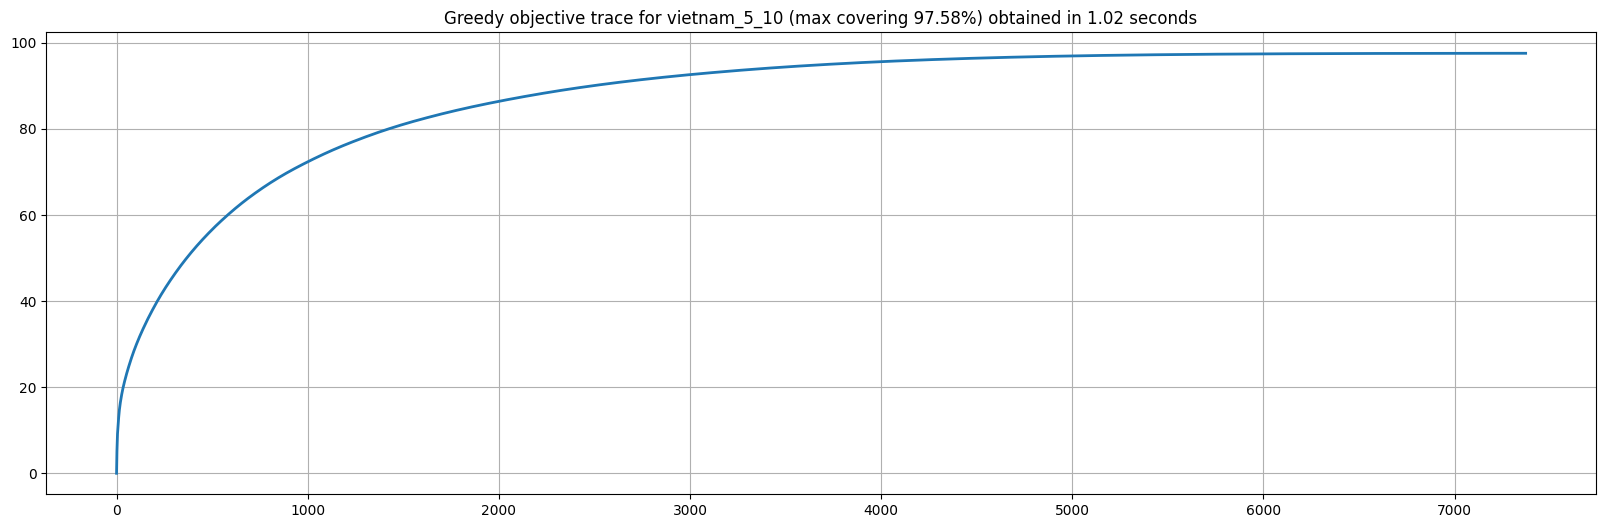

In [ ]:
plot_greedy_trace(
    result_greedy=result_greedy,
    tot_pop=tot_pop,
    strategy='Greedy',
    case=case,
    filename=fig_folder / f'greedy_trace_{case}.png',
    covered_pop=covered_pop,
)

In [ ]:
greedy_result, reduced_result, restricted, lifted_result = mch.greedy_drop_greedy(instance)

print(greedy_result.objective)
print(len(greedy_result.solution),greedy_result.solution)
print(len(reduced_result.solution),reduced_result.solution)
print(len(lifted_result.solution),lifted_result.solution)
print(lifted_result.objective)

94981864
7372 [5148, 34, 20, 5146, 5157, 65, 3804, 46, 1250, 5155, 33, 14, 17, 72, 58, 5632, 5680, 18, 55, 22, 1274, 51, 50, 731, 54, 6401, 5682, 12877, 13493, 219, 49, 5151, 6595, 5600, 2715, 3801, 1176, 5662, 7, 5602, 380, 4433, 13917, 11656, 11059, 5668, 9719, 5120, 8198, 1286, 2192, 5598, 5574, 9588, 5643, 12406, 75, 5139, 8705, 13585, 6206, 3417, 5133, 328, 6208, 5011, 2006, 6201, 5621, 1975, 10091, 1813, 133, 5690, 879, 5004, 8811, 66, 5584, 778, 71, 6, 13517, 12747, 5704, 3749, 3404, 5122, 13706, 45, 5015, 1240, 1230, 9597, 734, 5667, 719, 13407, 7974, 13981, 5646, 5629, 10833, 6225, 1273, 56, 1284, 5581, 9496, 6992, 209, 5026, 10876, 42, 13404, 5673, 12407, 13965, 774, 717, 5614, 8787, 871, 1158, 4987, 13454, 5162, 12762, 48, 5135, 865, 5640, 4986, 9528, 5605, 13444, 13993, 3624, 13265, 6358, 5145, 8769, 3402, 855, 165, 7351, 203, 3630, 13378, 3809, 12783, 6402, 13423, 5722, 4955, 8726, 5577, 5613, 8794, 8751, 12732, 12490, 11139, 1972, 12767, 3806, 13899, 13998, 5610, 889, 492

In [ ]:
greedy_result.total_time, reduced_result.total_time, lifted_result.total_time

(1.130331300002581, 0.061385900000459515, 3.5243270999999368)

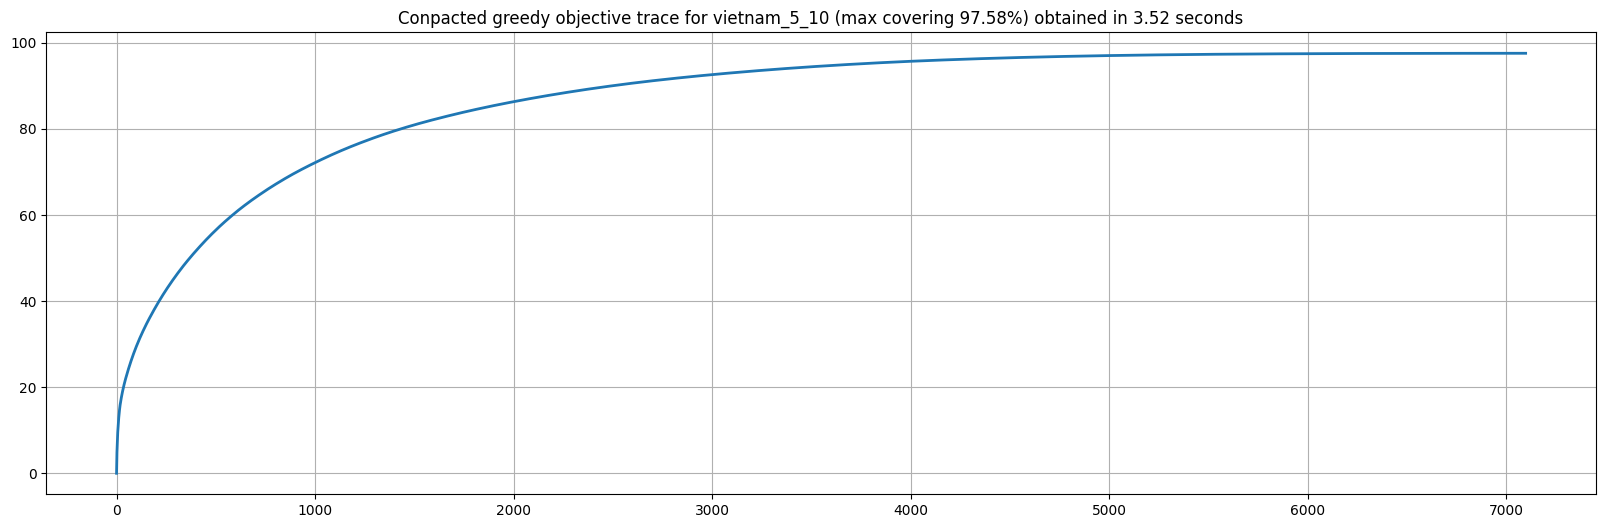

In [ ]:
plot_greedy_trace(
    result_greedy=lifted_result,
    tot_pop=tot_pop,
    strategy='Conpacted greedy',
    case=case,
    filename=fig_folder / f'compacted_greedy_trace_{case}.png',
    covered_pop=covered_pop,
)

In [ ]:
assert ( mch.greedy_result_to_dataframe_recompute(instance,lifted_result).value == mch.greedy_result_to_dataframe(lifted_result).value ).all()

True

In [ ]:
def plot_pareto_comparison(
    pareto: pd.DataFrame,
    joint,
    tot_pop: int | float,
    fig_folder,
    case: str,
) -> pd.DataFrame:
    '''Create comparison and gap plots for greedy, lifted, and Pareto results.'''
    import matplotlib.pyplot as plt

    common = pareto.index.intersection(joint.greedy.index)

    summary = pd.DataFrame(
        {
            'greedy': joint.greedy.loc[common],
            'lifted': joint.lifted.loc[common],
            'pareto': pareto.loc[common, 'value'],
        }
    ).astype(int)

    summary_pct = summary / tot_pop * 100
    gap_pct = pd.DataFrame(
        {
            'delta_greedy': (summary['pareto'] - summary['greedy']) / tot_pop * 100,
            'delta_lifted': (summary['pareto'] - summary['lifted']) / tot_pop * 100,
        }
    )

    ax = summary_pct.plot(figsize=(10, 3), grid=True, style=['-o', '-s', '-^'])
    ax.figure.savefig(
        fig_folder / f'pareto_vs_greedy_{case}.png',
        dpi=300,
        bbox_inches='tight',
    )
    plt.show()
    plt.close(ax.figure)

    ax = gap_pct.plot(figsize=(10, 3), grid=True)
    ax.figure.savefig(
        fig_folder / f'pareto_gap_{case}.png',
        dpi=300,
        bbox_inches='tight',
    )
    plt.show()
    plt.close(ax.figure)

    return summary


if run_gurobi:
    max_budget = len(result_greedy.solution)
    step = 50
    maxTimeInSeconds = 15*60

    pareto_file = datasets_folder / f'pareto_{case}_{maxTimeInSeconds}_{max_budget}_{step}.pkl'
    if pareto_file.exists():
        with open(pareto_file, 'rb') as f:
            pareto = pickle.load(f)
    else:
        pareto = mcs.OptimizeWithGurobipy(
            w,
            I,
            J,
            IJ,
            budget_list=range(0, max_budget + 1, step),
            maxTimeInSeconds=maxTimeInSeconds,
            progress=tqdm,
        )
        with open(pareto_file, 'wb') as f:
            pickle.dump(pareto, f)

    joint = pd.DataFrame(
        {
            'greedy': mch.greedy_result_to_dataframe(result_greedy)['value'],
            'lifted': mch.greedy_result_to_dataframe(lifted_result)['value'],
        }
    ).ffill()

    summary = plot_pareto_comparison(
            pareto=pareto,
            joint=joint,
            tot_pop=tot_pop,
            fig_folder=fig_folder,
            case=case,
        )

Set parameter Username
Set parameter LicenseID to value 2749948
Academic license - for non-commercial use only - expires 2026-12-04


  0%|          | 0/148 [00:00<?, ?it/s]